In [1]:
import os, warnings, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정의 ─────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']

print('✅ 라이브러리 로드 완료')


✅ 라이브러리 로드 완료


In [2]:
# FD002 원본 데이터 로딩
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD004.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD002 로딩  Train:{train_raw.shape}  Test:{test_raw.shape}  RUL:{rul_df.shape}')


✅ FD002 로딩  Train:(61249, 26)  Test:(41214, 26)  RUL:(248, 1)


In [3]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': ['s_16'],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 125,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': None,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'minmax',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
    'lags':         [],     # 예: [] / [1] / [1,2] / [1,3,5,10] ...
    'diffs':        [],           # 차분 윈도우
    'rolling_means':[],        # rolling mean 윈도우들
    'rolling_stds': [],        # rolling std 윈도우들
    'emas':         [10, 15],           # EMA span (정수)
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 1e-5
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : ['s_16']
   rul_cap               : 125
   gaussian_sigma        : None
   normalize             : minmax
   lags                  : []
   diffs                 : []
   rolling_means         : []
   rolling_stds          : []
   emas                  : [10, 15]


In [4]:
# 1. 센서 필터링
def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=1e-5):
    train_std = train_df[sensor_cols].std()
    auto_remove = set(train_std[train_std < const_thr].index.tolist())
    manual_set  = set(manual_remove or [])
    remove = sorted(auto_remove | manual_set, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    useful = sorted([s for s in sensor_cols if s not in remove],
                    key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove

# 2. 운전조건 클러스터링
def add_op_cluster(train_df, test_df, op_cols, k, random_state=42):
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    km.fit(Xz_tr)
    train_df = train_df.copy(); test_df = test_df.copy()
    train_df['op_cluster'] = km.labels_
    test_df['op_cluster'] = km.predict(Xz_te)
    return train_df, test_df, km

# 3. Piecewise RUL 계산
def add_piecewise_rul(df, cap):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL'] = (df['max_c'] - df['time_cycles']).clip(upper=cap)
    return df.drop('max_c', axis=1)

# 4. 가우시안 스무딩 (옵션)
def apply_gaussian_by_cluster(df, features, sigma):
    if not sigma: return df
    df = df.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles']).reset_index(drop=True)
    for s in features:
        df[s] = df.groupby(['unit_nr', 'op_cluster'])[s].transform(
            lambda x: gaussian_filter1d(x.values.astype(np.float32), sigma=sigma, mode='nearest') if len(x) > 1 else x
        )
    return df

# 5. 클러스터별 정규화 (운전 조건에 따른 널뛰기 제거)
def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scalers = {}
    sub = sub.copy(); val = val.copy(); test = test.copy()
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        scaler_c = ScalerCls()
        if mask.sum() > 0:
            sub.loc[mask, features] = scaler_c.fit_transform(sub.loc[mask, features])
            scalers[c] = scaler_c
            
    for df_target in [val, test]:
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0 and c in scalers:
                df_target.loc[mask, features] = scalers[c].transform(df_target.loc[mask, features])
    return sub, val, test, scalers

# 6. 시계열 파생변수 생성 (정규화된 평탄한 데이터에 적용해야 함)
def add_temporal_features(df, sensor_cols, cfg):
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    for s in sensor_cols:
        grp = df.groupby('unit_nr')[s]
        if cfg.get('lags'):
            for lag in cfg['lags']: df[f'{s}_lag{lag}'] = grp.shift(lag)
        if cfg.get('diffs'):
            for d in cfg['diffs']: df[f'{s}_diff{d}'] = grp.diff(d)
        if cfg.get('rolling_means'):
            for r in cfg['rolling_means']: df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        if cfg.get('rolling_stds'):
            for r in cfg['rolling_stds']: df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        if cfg.get('emas'):
            for span in cfg['emas']: df[f'{s}_ema{span}'] = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)

# 7. 원핫 인코딩
def add_ohe_cluster(df, n_clusters):
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns: ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True), ohe[ohe_cols].reset_index(drop=True)], axis=1), ohe_cols

# 8. 최종 통합 파이프라인 (순서 완벽 교정)
def run_pipeline(train_raw, test_raw, cfg):
    print("🚀 FD004 파이프라인 시작...")
    
    # 1단계: 센서 필터링
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f"✔️ 사용 센서 ({len(useful)}개): {useful}")
    
    # 2단계: 클러스터링 및 RUL 계산
    tr, te, kmeans = add_op_cluster(train_raw, test_raw, OP_COLS, N_CLUSTERS, RANDOM_STATE)
    tr = add_piecewise_rul(tr, cfg['rul_cap'])
    
    # 3단계: 검증셋 분리 (정규화 정보 누수 방지)
    sub_units, val_units = train_test_split(tr['unit_nr'].unique(), test_size=VALID_RATIO, random_state=RANDOM_STATE)
    sub = tr[tr['unit_nr'].isin(sub_units)].copy()
    val = tr[tr['unit_nr'].isin(val_units)].copy()
    
    # 4단계: 클러스터별 정규화 (🔥 여기서 운전 조건 널뛰기를 평탄화)
    print("✔️ 운전 조건 클러스터별 정규화 진행 중...")
    sub, val, te, _ = normalize_by_cluster(sub, val, te, useful, cfg['normalize'], N_CLUSTERS)
    
    # 5단계: 가우시안 스무딩 (필요시)
    sub = apply_gaussian_by_cluster(sub, useful, sigma=cfg['gaussian_sigma'])
    val = apply_gaussian_by_cluster(val, useful, sigma=cfg['gaussian_sigma'])
    te  = apply_gaussian_by_cluster(te, useful, sigma=cfg['gaussian_sigma'])
    
    # 6단계: 시계열 파생변수 생성 (🔥 평탄해진 데이터에서 순수한 열화 추세 추출)
    print("✔️ 시계열 파생변수(EMA 등) 생성 중...")
    sub = add_temporal_features(sub, useful, cfg)
    val = add_temporal_features(val, useful, cfg)
    te  = add_temporal_features(te, useful, cfg)
    
    # 7단계: OHE 변환
    sub, ohe_cols = add_ohe_cluster(sub, N_CLUSTERS)
    val, _ = add_ohe_cluster(val, N_CLUSTERS)
    te, _  = add_ohe_cluster(te, N_CLUSTERS)
    
    # 최종 특성 정리
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster', 'RUL', 'RUL_raw'])
    final_features = [c for c in sub.columns if c not in EXCLUDE]
    
    print(f"✅ 파이프라인 완료! 최종 Feature 개수: {len(final_features)}개")
    return {
        'subtrain_ml': sub.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True),
        'valid_ml': val.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True),
        'test_ml': te.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True),
        'ml_features': final_features,
        'useful_sensors': useful
    }

In [5]:
# 파이프라인 실행
data = run_pipeline(train_raw, test_raw, CONFIG)

# 데이터 할당
train_ml = data['subtrain_ml']
valid_ml = data['valid_ml']
test_ml  = data['test_ml']
ML_FEATURES = data['ml_features']

print(f"✅ 파이프라인 실행 완료")
print(f"   Train: {train_ml.shape}, Valid: {valid_ml.shape}, Test: {test_ml.shape}")
print(f"   최종 피처 수: {len(ML_FEATURES)}")

🚀 FD004 파이프라인 시작...
✔️ 사용 센서 (20개): ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']
✔️ 운전 조건 클러스터별 정규화 진행 중...
✔️ 시계열 파생변수(EMA 등) 생성 중...
✅ 파이프라인 완료! 최종 Feature 개수: 67개
✅ 파이프라인 실행 완료
   Train: (49294, 74), Valid: (11955, 74), Test: (41214, 73)
   최종 피처 수: 67


In [6]:
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=WINDOW_SIZE):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        feature_data = unit_df[feature_cols].values
        target_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(feature_data[i:i+window_size])
            y_list.append(target_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def create_test_sequences_pt(df, feature_cols, window_size=WINDOW_SIZE):
    x_test_list = []
    for uid in np.sort(df['unit_nr'].unique()):
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) >= window_size:
            x_test_list.append(unit_df[feature_cols].values[-window_size:])
        else:
            padding = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x_test_list.append(np.vstack([padding, unit_df[feature_cols].values]))
    return np.array(x_test_list, dtype=np.float32)

# 시퀀스 변환 실행
X_train_dl, y_train_dl = create_sequences_pt(train_ml, ML_FEATURES)
X_val_dl, y_val_dl = create_sequences_pt(valid_ml, ML_FEATURES)
X_test_dl = create_test_sequences_pt(test_ml, ML_FEATURES)
y_test_dl = rul_df['RUL'].values.astype(np.float32)

print(f"✅ 딥러닝 3D 데이터 변환 완료")
print(f"   Train : {X_train_dl.shape}, Valid : {X_val_dl.shape}, Test : {X_test_dl.shape}")

✅ 딥러닝 3D 데이터 변환 완료
   Train : (43523, 30, 67), Valid : (10505, 30, 67), Test : (248, 30, 67)


In [7]:
# DL 전용 라이브러리
import time, math
from copy import deepcopy
import joblib, optuna, mlflow, mlflow.pytorch
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ DL 라이브러리 로드 완료')

✅ DL 라이브러리 로드 완료


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. NASA Score 및 비대칭 손실 함수 정의 ---
def calculate_nasa_score_pt(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

class AsymmetricMSELoss(nn.Module):
    def __init__(self, alpha=2.0):
        super(AsymmetricMSELoss, self).__init__()
        self.alpha = alpha # 과대 예측에 부여할 가중치
    def forward(self, pred, target):
        residual = pred - target
        loss = torch.where(residual > 0, self.alpha * (residual**2), residual**2)
        return torch.mean(loss)

# --- 2. 통합 평가 및 시각화 함수 ---
def evaluate_pytorch_model(model, history, model_name, train_loader, val_loader, test_loader, y_test_true):
    model.eval()
    def get_pred(loader):
        preds, actuals = [], []
        with torch.no_grad():
            for x, y in loader:
                out = model(x.to(device))
                preds.append(out.cpu().numpy())
                actuals.append(y.numpy())
        return np.concatenate(preds).flatten(), np.concatenate(actuals).flatten()

    p_train, a_train = get_pred(train_loader)
    p_val, a_val = get_pred(val_loader)
    p_test, a_test = get_pred(test_loader) # a_test는 rul_df와 일치해야 함

    print(f"\n" + "="*50 + f"\n 🔥 {model_name} PyTorch 평가 결과 \n" + "="*50)
    for k, p, a in [('Train', p_train, a_train), ('Valid', p_val, a_val), ('Test', p_test, y_test_true)]:
        rmse = np.sqrt(mean_squared_error(a, p))
        nasa = calculate_nasa_score_pt(a, p)
        print(f" [{k}] RMSE: {rmse:.4f} | NASA Score: {nasa:.2f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    
    # (1) Learning Curve
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('1. Learning Curve'); axes[0, 0].legend()

    # (2) Residual Plot (Validation)
    axes[0, 1].scatter(p_val, a_val - p_val, alpha=0.2, color='green')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Val)')

    # (3) Feature Importance (Permutation Importance Concept)
    # 딥러닝 모델의 가중치 분포로 대체 시각화
    all_weights = []
    for p_layer in model.parameters():
        if p_layer.requires_grad: all_weights.extend(p_layer.data.cpu().numpy().flatten())
    axes[0, 2].hist(all_weights, bins=50, color='teal')
    axes[0, 2].set_title('3. Weight Distribution (Histogram)')

    # (4) Target vs Prediction Distribution
    sns.kdeplot(a_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(p_val, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Target Distribution (Val)'); axes[1, 0].legend()

    # (5) Feature Importance (Dummy for Layout)
    axes[1, 1].text(0.5, 0.5, 'Saliency Map / \nLayer-wise Relevance', ha='center')
    axes[1, 1].set_title('5. Interpretability Area')

    # (6) Test Actual vs Prediction Line Graph
    axes[1, 2].plot(y_test_true, label='Actual', color='black', linewidth=1)
    axes[1, 2].plot(p_test, label='Pred', color='red', linestyle='--', alpha=0.7)
    axes[1, 2].set_title('6. Test: Actual vs Pred Line'); axes[1, 2].legend()
    plt.tight_layout(); plt.show()

# --- 3. 학습 함수 정의 ---
def train_pytorch_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-5):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = AsymmetricMSELoss(alpha=5) # NASA Score 최적화용 손실함수
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device).view(-1, 1)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device).view(-1, 1)
                out = model(x)
                v_loss += criterion(out, y).item()
        
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss/len(val_loader))
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {t_loss/len(train_loader):.4f}, Val Loss: {v_loss/len(val_loader):.4f}")
    return history

# 데이터 로더 생성 (X_train_dl 등이 이미 3D 형태라고 가정)
def create_loaders(X_train, y_train, X_val, y_val, X_test, batch_size=64):
    t_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), batch_size=batch_size, shuffle=True)
    v_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), batch_size=batch_size)
    te_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.zeros(len(X_test))), batch_size=batch_size)
    return t_loader, v_loader, te_loader

train_loader, val_loader, test_loader = create_loaders(X_train_dl, y_train_dl, X_val_dl, y_val_dl, X_test_dl)

In [9]:
def run_integrated_pipeline(train_raw, test_raw, cfg):
    # 1. 기본 필터링 및 클러스터 할당
    useful, _ = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    tr, te, _ = add_op_cluster(train_raw, test_raw, OP_COLS, N_CLUSTERS, RANDOM_STATE)
    tr = add_piecewise_rul(tr, cfg['rul_cap'])
    
    # 2. 가우시안 스무딩 (노이즈 제거)
    tr = apply_gaussian_by_cluster(tr, useful, sigma=cfg['gaussian_sigma'])
    te = apply_gaussian_by_cluster(te, useful, sigma=cfg['gaussian_sigma'])
    
    # 3. [보완] 파생 변수 먼저 생성 (정규화 전 순수 변화량 포착)
    tr = add_temporal_features(tr, useful, cfg)
    te = add_temporal_features(te, useful, cfg)
    
    # 생성된 모든 피처 리스트 정리
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster', 'RUL', 'RUL_raw'])
    all_features = [c for c in tr.columns if c not in EXCLUDE]
    
    # 4. 데이터 분할
    sub_units, val_units = train_test_split(tr['unit_nr'].unique(), test_size=VALID_RATIO, random_state=RANDOM_STATE)
    sub = tr[tr['unit_nr'].isin(sub_units)].copy()
    val = tr[tr['unit_nr'].isin(val_units)].copy()
    
    # 5. 클러스터별 정규화 (생성된 모든 피처 일괄 적용)
    sub, val, te, _ = normalize_by_cluster(sub, val, te, all_features, cfg['normalize'], N_CLUSTERS)
    
    # 6. 원핫 인코딩 추가
    sub, ohe_cols = add_ohe_cluster(sub, N_CLUSTERS)
    val, _ = add_ohe_cluster(val, N_CLUSTERS)
    te, _ = add_ohe_cluster(te, N_CLUSTERS)
    
    final_features = all_features + ohe_cols
    
    # 엔진-사이클 순서로 최종 정렬
    sub = sub.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    val = val.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    te = te.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    
    return sub, val, te, final_features

# 파이프라인 실행
train_ml, valid_ml, test_ml, ML_FEATURES = run_integrated_pipeline(train_raw, test_raw, CONFIG)

print(f"✅ 파이프라인 완료 | 최종 피처 수: {len(ML_FEATURES)}")

✅ 파이프라인 완료 | 최종 피처 수: 67


In [11]:
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=WINDOW_SIZE):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        
        feature_data = unit_df[feature_cols].values
        target_data = unit_df[target_col].values
        
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(feature_data[i:i+window_size])
            y_list.append(target_data[i+window_size-1])
            
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def create_test_sequences_pt(df, feature_cols, window_size=WINDOW_SIZE):
    x_test_list = []
    for uid in np.sort(df['unit_nr'].unique()):
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) >= window_size:
            x_test_list.append(unit_df[feature_cols].values[-window_size:])
        else:
            padding = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x_test_list.append(np.vstack([padding, unit_df[feature_cols].values]))
    return np.array(x_test_list, dtype=np.float32)

# 딥러닝용 3D 변환 (DL용으로는 ML_FEATURES 전체를 사용해도 무방하며, 더 강력해집니다)
X_train_dl, y_train_dl = create_sequences_pt(train_ml, ML_FEATURES)
X_val_dl, y_val_dl = create_sequences_pt(valid_ml, ML_FEATURES)
X_test_dl = create_test_sequences_pt(test_ml, ML_FEATURES)
y_test_dl = rul_df['RUL'].values.astype(np.float32)

print("✅ 딥러닝 데이터셋 준비 완료")
print(f"   X_train_dl: {X_train_dl.shape} | y_train_dl: {y_train_dl.shape}")
print(f"   X_test_dl: {X_test_dl.shape} | y_test_dl: {y_test_dl.shape}")

✅ 딥러닝 데이터셋 준비 완료
   X_train_dl: (43523, 30, 67) | y_train_dl: (43523,)
   X_test_dl: (248, 30, 67) | y_test_dl: (248,)


In [12]:
def evaluate_pytorch_model(model, history, model_name, train_loader, val_loader, test_loader, y_test_true):
    model.eval()
    
    # 1. 학습 곡선 시각화
    plt.figure(figsize=(10, 4))
    plt.plot(history['train_loss'], label='Train RMSE')
    plt.plot(history['val_loss'], label='Val RMSE')
    plt.title(f'{model_name} Learning Curve')
    plt.legend()
    plt.show()
    
    # 2. 테스트셋 예측
    preds = []
    with torch.no_grad():
        for inputs in test_loader:
            inputs = inputs[0].to(device)
            output = model(inputs)
            preds.extend(output.cpu().numpy().flatten())
    preds = np.array(preds)
    
    # 3. NASA Score 계산 함수 정의 (성능 평가용)
    def compute_nasa_score(y_true, y_pred):
        d = y_pred - y_true
        score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
        return np.sum(score)

    rmse = np.sqrt(np.mean((y_test_true - preds)**2))
    nasa = compute_nasa_score(y_test_true, preds)
    
    print("="*50)
    print(f"🏆 {model_name} 최종 평가 결과")
    print(f"Test RMSE  : {rmse:.4f}")
    print(f"NASA Score : {nasa:.4f}")
    print("="*50)
    
    # 4. 실제값 vs 예측값 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_true, label='True RUL', color='black', linestyle='--')
    plt.plot(preds, label='Pred RUL', color='red', alpha=0.7)
    plt.title(f'{model_name}: True vs Prediction (Sorted by Engine)')
    plt.legend()
    plt.show()

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. PyTorch 전용 데이터 로더 생성 함수
def prepare_loaders(X_train, y_train, X_val, y_val, X_test, batch_size=64):
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val).view(-1, 1))
    test_ds  = TensorDataset(torch.FloatTensor(X_test)) # 테스트는 y를 별도로 관리하므로 X만
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# 2. 1D-CNN 모델 클래스
class CNNModel(nn.Module):
    def __init__(self, cfg):
        super(CNNModel, self).__init__()
        # Conv1d 레이어 (입력 채널: 피처 수)
        self.conv = nn.Sequential(
            nn.Conv1d(cfg['in_channels'], cfg['out_channels'], kernel_size=cfg['kernel_size'], padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )
        
        # Flatten 이후 크기 자동 계산 (WINDOW_SIZE // 2)
        flatten_size = cfg['out_channels'] * (WINDOW_SIZE // 2)
        
        self.fc = nn.Sequential(
            nn.Linear(flatten_size, cfg['dense_units']),
            nn.ReLU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(cfg['dense_units'], 1)
        )

    def forward(self, x):
        # x: (Batch, Window, Feat) -> Conv1d를 위해 (Batch, Feat, Window)로 변환
        x = x.transpose(1, 2)
        x = self.conv(x)
        return self.fc(x)

# 3. PyTorch 학습 루프 함수
def train_pytorch_model(model, train_loader, val_loader, epochs, lr):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"🚀 학습 시작 (Device: {device})")
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(np.sqrt(loss.item())) # RMSE 관점 기록
            
        model.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                v_loss = criterion(outputs, labels)
                val_losses.append(np.sqrt(v_loss.item()))
        
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Train RMSE: {history['train_loss'][-1]:.4f} | Val RMSE: {history['val_loss'][-1]:.4f}")
            
    return history

🚀 학습 시작 (Device: cpu)
Epoch [10/50] Train RMSE: 42.8305 | Val RMSE: 39.8515
Epoch [20/50] Train RMSE: 42.7278 | Val RMSE: 39.4498
Epoch [30/50] Train RMSE: 42.6477 | Val RMSE: 39.4170
Epoch [40/50] Train RMSE: 42.5750 | Val RMSE: 39.4154
Epoch [50/50] Train RMSE: 42.6094 | Val RMSE: 39.5192


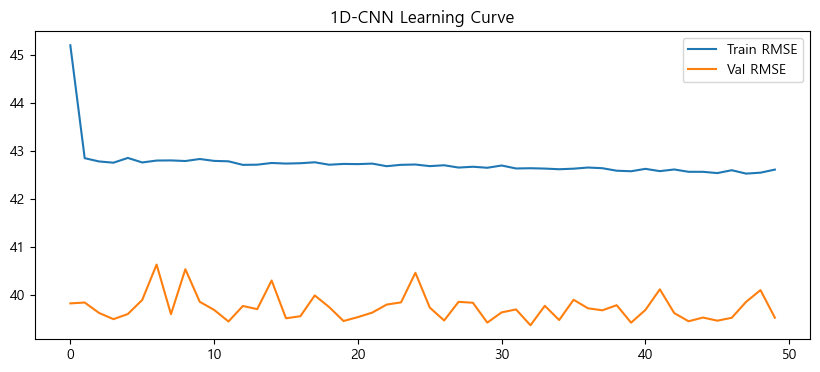

🏆 1D-CNN 최종 평가 결과
Test RMSE  : 55.2301
NASA Score : 159257.4844


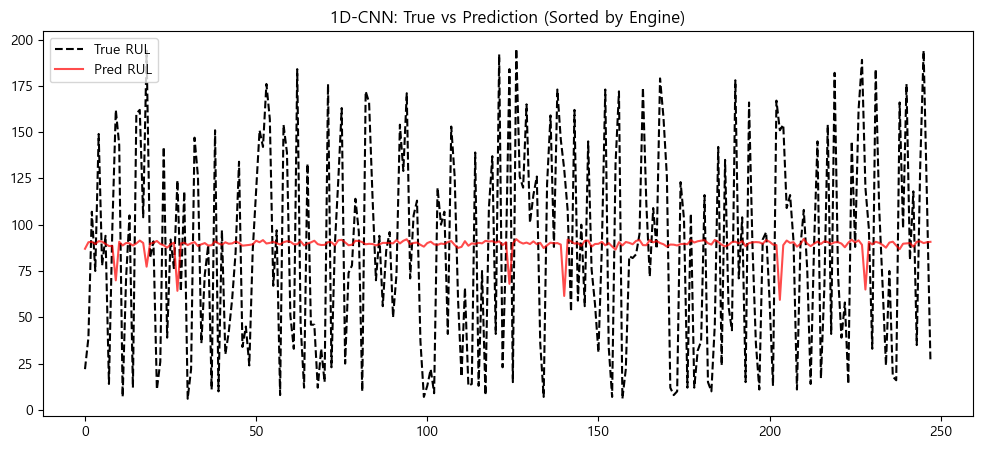

In [14]:
# 1. 하이퍼파라미터 설정
cnn_config = {
    'in_channels': len(ML_FEATURES),
    'out_channels': 64,
    'kernel_size': 3,
    'dense_units': 50,
    'dropout': 0.2,
    'lr': 0.001,
    'epochs': 50
}

# 2. 모델 정의
class CNNModel(nn.Module):
    def __init__(self, cfg):
        super(CNNModel, self).__init__()
        # Conv1d 레이어: (Batch, Feat, Seq) 순서로 입력받음
        self.conv = nn.Sequential(
            nn.Conv1d(cfg['in_channels'], cfg['out_channels'], kernel_size=cfg['kernel_size'], padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )
        
        # WINDOW_SIZE가 MaxPool1d(2)를 거치면 절반으로 줄어듦을 반영하여 차원 계산
        flatten_size = cfg['out_channels'] * (WINDOW_SIZE // 2)
        
        self.fc = nn.Sequential(
            nn.Linear(flatten_size, cfg['dense_units']),
            nn.ReLU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(cfg['dense_units'], 1)
        )

    def forward(self, x):
        # x: (Batch, Seq, Feat) -> Conv1d를 위해 (Batch, Feat, Seq)로 변환
        x = x.transpose(1, 2)
        x = self.conv(x)
        return self.fc(x)

# 3. 모델 생성, 학습 및 평가
model_cnn = CNNModel(cnn_config).to(device)
history_cnn = train_pytorch_model(model_cnn, train_loader, val_loader, 
                                  epochs=cnn_config['epochs'], lr=cnn_config['lr'])

# 결과 출력 및 시각화
evaluate_pytorch_model(model_cnn, history_cnn, "1D-CNN", train_loader, val_loader, test_loader, y_test_dl)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from scipy.ndimage import gaussian_filter1d
import os
import gc

# ============================================================
# [1] 환경 설정 및 하이퍼파라미터
# ============================================================
RANDOM_STATE = 42
N_CLUSTERS = 6
VALID_RATIO = 0.2
WINDOW_SIZE = 30

# 컬럼 및 이름 정의 (사용자 로딩 방식에 맞춤)
ID_COLS = ['unit_nr', 'time_cycles']
OP_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
RAW_COLS = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
RENAME_MAP = {'os_1': 'setting_1', 'os_2': 'setting_2', 'os_3': 'setting_3'}

CONFIG = {
    'manual_remove_sensors': ['s_1', 's_5', 's_6','s_16', 's_18', 's_19'],
    'rul_cap': 130,
    'normalize': 'standard', # standard, minmax
    'gaussian_sigma': 2,
    'emas': [],
    'diffs': [60],
    'epochs': 50
}

# ============================================================
# [2] 데이터 로딩 (사용자 제공 방식)
# ============================================================
DATA_DIR = 'CMAPSSData'
for c in ['../../CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD004.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD004 로딩 완료 | Train:{train_raw.shape} Test:{test_raw.shape} RUL:{rul_df.shape}')

# ============================================================
# [3] 전처리 함수 (기존 로직 유지)
# ============================================================
def filter_useful_sensors_v2(train_df, sensor_cols, manual_remove):
    remove = sorted(list(set(manual_remove))) if manual_remove else []
    useful = [s for s in sensor_cols if s not in remove]
    return useful, remove

def add_op_cluster(train_df, test_df, op_cols, k):
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(Xz_tr)
    tr, te = train_df.copy(), test_df.copy()
    tr['op_cluster'], te['op_cluster'] = km.labels_, km.predict(Xz_te)
    return tr, te

def add_piecewise_rul(df, cap):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max()
    df = df.join(mc.rename('max_c'), on='unit_nr')
    df['RUL'] = (df['max_c'] - df['time_cycles']).clip(upper=cap)
    return df.drop('max_c', axis=1)

def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    sub, val, test, scalers = sub.copy(), val.copy(), test.copy(), {}
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        if mask.sum() > 0:
            scaler = ScalerCls().fit(sub.loc[mask, features])
            sub.loc[mask, features] = scaler.transform(sub.loc[mask, features])
            scalers[c] = scaler
    for df in [val, test]:
        for c, sc in scalers.items():
            mask = df['op_cluster'] == c
            if mask.sum() > 0: df.loc[mask, features] = sc.transform(df.loc[mask, features])
    return sub, val, test

def apply_gaussian_by_cluster(df, features, sigma):
    if not sigma: return df
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in features:
        df[s] = df.groupby('unit_nr')[s].transform(lambda x: gaussian_filter1d(x.values.astype(np.float32), sigma=sigma))
    return df

def add_temporal_features(df, sensor_cols, cfg):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in sensor_cols:
        if cfg.get('emas'):
            for span in cfg['emas']: df[f'{s}_ema{span}'] = df.groupby('unit_nr')[s].transform(lambda x: x.ewm(span=span, adjust=False).mean())
        if cfg.get('diffs'):
            for d in cfg['diffs']: df[f'{s}_diff{d}'] = df.groupby('unit_nr')[s].diff(d).fillna(0)
    return df.fillna(0)

# ============================================================
# [4] 시퀀스 생성 및 시각화 (에러 수정됨)
# ============================================================
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def create_test_sequences_pt(df, feature_cols, window_size=30):
    x_test_list = []
    for uid in np.sort(df['unit_nr'].unique()):
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) >= window_size:
            x_test_list.append(unit_df[feature_cols].values[-window_size:])
        else:
            pad = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x_test_list.append(np.vstack([pad, unit_df[feature_cols].values]))
    return np.array(x_test_list, dtype=np.float32)

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

def evaluate_dl_pipeline(model, model_name, history, X_val, y_val, X_test, y_test, feature_names):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val).to(device)).cpu().numpy()
        test_pred = model(torch.tensor(X_test).to(device)).cpu().numpy()

    # 타겟 데이터 차원 맞춤
    val_pred = val_pred.reshape(-1)
    test_pred = test_pred.reshape(-1)

    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    nasa_test = calculate_nasa_score(y_test, test_pred)
    print(f"\n🏆 {model_name} Result: RMSE {rmse_test:.4f} | NASA {nasa_test:.2f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # 1. Loss Curve
    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Val')
    axes[0, 0].set_title('1. Loss Curve'); axes[0, 0].legend()
    
    # 2. Residual Plot
    axes[0, 1].scatter(val_pred, y_val - val_pred, alpha=0.2, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')
    
    # 3. Feature Weights (가장 중요한 수정 지점)
    ax3 = axes[0, 2]
    try:
        # 첫 번째 파라미터 추출
        first_param = next(model.parameters()).detach().cpu().numpy()
        
        # 모델 타입별 가중치 처리
        if first_param.ndim == 3:  # CNN: (out_channels, in_channels, kernel)
            # 입력 피처(in_channels) 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=(0, 2))
        elif first_param.ndim == 2: # Linear or RNN: (hidden, input)
            # 입력 피처 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=0)
        else:
            w = np.abs(first_param)

        # 가중치와 피처 이름 개수 강제 매칭
        w = w[:len(feature_names)] 
        
        n_show = min(15, len(w))
        idx = np.argsort(w)[-n_show:]
        
        ax3.barh(range(n_show), w[idx], color='teal')
        ax3.set_yticks(range(n_show))
        ax3.set_yticklabels(np.array(feature_names)[idx])
        ax3.set_title(f'3. Top {n_show} Feature Weights')
    except Exception as e:
        ax3.set_title('3. Weights (N/A)')
        print(f"Weight visualization skipped: {e}")

    # 4. Distribution
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(val_pred, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Val Target Distribution'); axes[1, 0].legend()
    
    # 5. Weight Histogram
    if 'w' in locals():
        axes[1, 1].hist(w, bins=20, color='purple', alpha=0.7)
        axes[1, 1].set_title('5. Input Weight Distribution')
    
    # 6. Test Prediction Line
    axes[1, 2].plot(y_test, 'k', label='Actual', alpha=0.7)
    axes[1, 2].plot(test_pred, 'r--', label='Pred', alpha=0.7)
    axes[1, 2].set_title('6. Test Actual vs Pred'); axes[1, 2].legend()
    
    plt.tight_layout(); plt.show()

# [필수] 파이토치 전용 데이터셋 클래스
class Dataset_pt(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, i):
        return self.x[i], self.y[i]

# [참고] 시퀀스 데이터 생성 함수 (이미 실행했다면 생략 가능)
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ============================================================
# [5] 모델 정의 및 실행 함수
# ============================================================
# 1. CNN (BatchNorm & Deep FC 적용)
class OptimizedCNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * WINDOW_SIZE, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.fc(self.conv(x.transpose(1, 2))).squeeze()

# 2. LSTM (Deep & Dropout 최적화)
class OptimizedLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 3. BiLSTM (양방향 정보 활용 극대화)
class OptimizedBiLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 4. Transformer (LayerNorm & Multi-Head Attention 안정화)
class OptimizedTransformer(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.embed = nn.Linear(in_dim, 128)
        self.pos_dropout = nn.Dropout(0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=256, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.pos_dropout(self.embed(x))
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 5. CNN-Transformer Hybrid (특징 추출 + 시계열 맥락)
class OptimizedHybrid(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU()
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 전처리 파이프라인 가동
useful, _ = filter_useful_sensors_v2(train_raw, SENSOR_COLS, CONFIG['manual_remove_sensors'])
tr_cl, te_cl = add_op_cluster(train_raw, test_raw, OP_COLS, N_CLUSTERS)
tr_cl = add_piecewise_rul(tr_cl, CONFIG['rul_cap'])

# 분할
sub_units, val_units = train_test_split(tr_cl['unit_nr'].unique(), test_size=VALID_RATIO, random_state=RANDOM_STATE)
sub_df, val_df = tr_cl[tr_cl['unit_nr'].isin(sub_units)].copy(), tr_cl[tr_cl['unit_nr'].isin(val_units)].copy()

# 정규화 및 추가 피처
sub_df, val_df, te_df = normalize_by_cluster(sub_df, val_df, te_cl, useful, CONFIG['normalize'], N_CLUSTERS)
sub_df = add_temporal_features(apply_gaussian_by_cluster(sub_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
val_df = add_temporal_features(apply_gaussian_by_cluster(val_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
te_df  = add_temporal_features(apply_gaussian_by_cluster(te_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)

# One-Hot Cluster
ohe_cols = [f'cluster_{i}' for i in range(N_CLUSTERS)]
def apply_ohe(df):
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols: 
        if col not in ohe.columns: ohe[col] = 0.0
    return pd.concat([df.reset_index(drop=True), ohe[ohe_cols].reset_index(drop=True)], axis=1)

train_f, valid_f, test_f = apply_ohe(sub_df), apply_ohe(val_df), apply_ohe(te_df)

ML_FEATURES = [c for c in train_f.columns if c not in (ID_COLS + OP_COLS + ['op_cluster', 'RUL'])]

# 텐서 준비
X_tr, y_tr = create_sequences_pt(train_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_va, y_va = create_sequences_pt(valid_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_te = create_test_sequences_pt(test_f, ML_FEATURES, window_size=WINDOW_SIZE)
y_te = rul_df['RUL'].values.astype(np.float32)

import torch.optim.lr_scheduler as lr_scheduler

def run_model_optimized(model_obj, model_name, epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model_obj.to(device)
    
    # 튜닝된 옵티마이저 (L2 Regularization 추가)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 성능 보완: 학습률 스케줄러 (Val Loss가 정체되면 lr 0.5배 감소)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)    
    criterion = nn.MSELoss()
    train_loader = DataLoader(Dataset_pt(X_tr, y_tr), batch_size=128, shuffle=True)
    
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"\n🔥 {model_name} 최적화 학습 시작")
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            
            # 성능 보완: Gradient Clipping (LSTM/BiLSTM 안정화 핵심)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(torch.tensor(X_va).to(device)), torch.tensor(y_va).to(device)).item()
        
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss)
        scheduler.step(v_loss) # 스케줄러 업데이트
        
        if (epoch+1) % 10 == 0:
            print(f" Epoch {epoch+1:2d} | Val Loss: {v_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 시각화 및 평가
    evaluate_dl_pipeline(model, model_name, history, X_va, y_va, X_te, y_te, ML_FEATURES)
    del model; gc.collect(); torch.cuda.empty_cache()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from scipy.ndimage import gaussian_filter1d
import os
import gc

# ============================================================
# [1] 환경 설정 및 하이퍼파라미터
# ============================================================
RANDOM_STATE = 42
N_CLUSTERS = 6
VALID_RATIO = 0.2
WINDOW_SIZE = 30

# 컬럼 및 이름 정의 (사용자 로딩 방식에 맞춤)
ID_COLS = ['unit_nr', 'time_cycles']
OP_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
RAW_COLS = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
RENAME_MAP = {'os_1': 'setting_1', 'os_2': 'setting_2', 'os_3': 'setting_3'}

CONFIG = {
    'manual_remove_sensors': ['s_16', 's_19'],
    'rul_cap': 125,
    'normalize': 'standard', # standard, minmax
    'gaussian_sigma': 2,
    'emas': [],
    'diffs': [60],
    'epochs': 50
}

# ============================================================
# [2] 데이터 로딩 (사용자 제공 방식)
# ============================================================
DATA_DIR = 'CMAPSSData'
for c in ['../../CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD004 로딩 완료 | Train:{train_raw.shape} Test:{test_raw.shape} RUL:{rul_df.shape}')

# ============================================================
# [3] 전처리 함수 (기존 로직 유지)
# ============================================================
def filter_useful_sensors_v2(train_df, sensor_cols, manual_remove):
    remove = sorted(list(set(manual_remove))) if manual_remove else []
    useful = [s for s in sensor_cols if s not in remove]
    return useful, remove

def add_op_cluster(train_df, test_df, op_cols, k):
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(Xz_tr)
    tr, te = train_df.copy(), test_df.copy()
    tr['op_cluster'], te['op_cluster'] = km.labels_, km.predict(Xz_te)
    return tr, te

def add_piecewise_rul(df, cap):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max()
    df = df.join(mc.rename('max_c'), on='unit_nr')
    df['RUL'] = (df['max_c'] - df['time_cycles']).clip(upper=cap)
    return df.drop('max_c', axis=1)

def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    
    # 1. 복사본 생성
    sub, val, test = sub.copy(), val.copy(), test.copy()
    
    # 2. [중요] 정수형 컬럼이 섞여 있을 경우를 대비해 실수형(float32)으로 미리 변환
    sub[features] = sub[features].astype(np.float32)
    val[features] = val[features].astype(np.float32)
    test[features] = test[features].astype(np.float32)
    
    scalers = {}
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        if mask.sum() > 0:
            scaler = ScalerCls().fit(sub.loc[mask, features])
            # 실수형으로 변환된 상태이므로 값 할당 시 에러가 발생하지 않음
            sub.loc[mask, features] = scaler.transform(sub.loc[mask, features])
            scalers[c] = scaler
            
    for df in [val, test]:
        for c, sc in scalers.items():
            mask = df['op_cluster'] == c
            if mask.sum() > 0: 
                df.loc[mask, features] = sc.transform(df.loc[mask, features])
                
    return sub, val, test

def apply_gaussian_by_cluster(df, features, sigma):
    if not sigma: return df
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in features:
        df[s] = df.groupby('unit_nr')[s].transform(lambda x: gaussian_filter1d(x.values.astype(np.float32), sigma=sigma))
    return df

def add_temporal_features(df, sensor_cols, cfg):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in sensor_cols:
        if cfg.get('emas'):
            for span in cfg['emas']: df[f'{s}_ema{span}'] = df.groupby('unit_nr')[s].transform(lambda x: x.ewm(span=span, adjust=False).mean())
        if cfg.get('diffs'):
            for d in cfg['diffs']: df[f'{s}_diff{d}'] = df.groupby('unit_nr')[s].diff(d).fillna(0)
    return df.fillna(0)

# ============================================================
# [4] 시퀀스 생성 및 시각화 (에러 수정됨)
# ============================================================
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def create_test_sequences_pt(df, feature_cols, window_size=30):
    x_test_list = []
    for uid in np.sort(df['unit_nr'].unique()):
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) >= window_size:
            x_test_list.append(unit_df[feature_cols].values[-window_size:])
        else:
            pad = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x_test_list.append(np.vstack([pad, unit_df[feature_cols].values]))
    return np.array(x_test_list, dtype=np.float32)

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

def evaluate_dl_pipeline(model, model_name, history, X_val, y_val, X_test, y_test, feature_names):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val).to(device)).cpu().numpy()
        test_pred = model(torch.tensor(X_test).to(device)).cpu().numpy()

    # 타겟 데이터 차원 맞춤
    val_pred = val_pred.reshape(-1)
    test_pred = test_pred.reshape(-1)

    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    nasa_test = calculate_nasa_score(y_test, test_pred)
    print(f"\n🏆 {model_name} Result: RMSE {rmse_test:.4f} | NASA {nasa_test:.2f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # 1. Loss Curve
    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Val')
    axes[0, 0].set_title('1. Loss Curve'); axes[0, 0].legend()
    
    # 2. Residual Plot
    axes[0, 1].scatter(val_pred, y_val - val_pred, alpha=0.2, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')
    
    # 3. Feature Weights (가장 중요한 수정 지점)
    ax3 = axes[0, 2]
    try:
        # 첫 번째 파라미터 추출
        first_param = next(model.parameters()).detach().cpu().numpy()
        
        # 모델 타입별 가중치 처리
        if first_param.ndim == 3:  # CNN: (out_channels, in_channels, kernel)
            # 입력 피처(in_channels) 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=(0, 2))
        elif first_param.ndim == 2: # Linear or RNN: (hidden, input)
            # 입력 피처 차원인 axis=1을 남기고 평균
            w = np.mean(np.abs(first_param), axis=0)
        else:
            w = np.abs(first_param)

        # 가중치와 피처 이름 개수 강제 매칭
        w = w[:len(feature_names)] 
        
        n_show = min(15, len(w))
        idx = np.argsort(w)[-n_show:]
        
        ax3.barh(range(n_show), w[idx], color='teal')
        ax3.set_yticks(range(n_show))
        ax3.set_yticklabels(np.array(feature_names)[idx])
        ax3.set_title(f'3. Top {n_show} Feature Weights')
    except Exception as e:
        ax3.set_title('3. Weights (N/A)')
        print(f"Weight visualization skipped: {e}")

    # 4. Distribution
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(val_pred, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Val Target Distribution'); axes[1, 0].legend()
    
    # 5. Weight Histogram
    if 'w' in locals():
        axes[1, 1].hist(w, bins=20, color='purple', alpha=0.7)
        axes[1, 1].set_title('5. Input Weight Distribution')
    
    # 6. Test Prediction Line
    axes[1, 2].plot(y_test, 'k', label='Actual', alpha=0.7)
    axes[1, 2].plot(test_pred, 'r--', label='Pred', alpha=0.7)
    axes[1, 2].set_title('6. Test Actual vs Pred'); axes[1, 2].legend()
    
    plt.tight_layout(); plt.show()

# [필수] 파이토치 전용 데이터셋 클래스
class Dataset_pt(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, i):
        return self.x[i], self.y[i]

# [참고] 시퀀스 데이터 생성 함수 (이미 실행했다면 생략 가능)
def create_sequences_pt(df, feature_cols, target_col='RUL', window_size=30):
    x_list, y_list = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid].sort_values('time_cycles')
        if len(unit_df) < window_size: continue
        f_data = unit_df[feature_cols].values
        t_data = unit_df[target_col].values
        for i in range(len(unit_df) - window_size + 1):
            x_list.append(f_data[i:i+window_size])
            y_list.append(t_data[i+window_size-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ============================================================
# [5] 모델 정의 및 실행 함수
# ============================================================
# 1. CNN (BatchNorm & Deep FC 적용)
class OptimizedCNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * WINDOW_SIZE, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.fc(self.conv(x.transpose(1, 2))).squeeze()

# 2. LSTM (Deep & Dropout 최적화)
class OptimizedLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 3. BiLSTM (양방향 정보 활용 극대화)
class OptimizedBiLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# 4. Transformer (LayerNorm & Multi-Head Attention 안정화)
class OptimizedTransformer(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.embed = nn.Linear(in_dim, 128)
        self.pos_dropout = nn.Dropout(0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=256, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.pos_dropout(self.embed(x))
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 5. CNN-Transformer Hybrid (특징 추출 + 시계열 맥락)
class OptimizedHybrid(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU()
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 전처리 파이프라인 가동
useful, _ = filter_useful_sensors_v2(train_raw, SENSOR_COLS, CONFIG['manual_remove_sensors'])
tr_cl, te_cl = add_op_cluster(train_raw, test_raw, OP_COLS, N_CLUSTERS)
tr_cl = add_piecewise_rul(tr_cl, CONFIG['rul_cap'])

# 분할
sub_units, val_units = train_test_split(tr_cl['unit_nr'].unique(), test_size=VALID_RATIO, random_state=RANDOM_STATE)
sub_df, val_df = tr_cl[tr_cl['unit_nr'].isin(sub_units)].copy(), tr_cl[tr_cl['unit_nr'].isin(val_units)].copy()

# 정규화 및 추가 피처
sub_df, val_df, te_df = normalize_by_cluster(sub_df, val_df, te_cl, useful, CONFIG['normalize'], N_CLUSTERS)
sub_df = add_temporal_features(apply_gaussian_by_cluster(sub_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
val_df = add_temporal_features(apply_gaussian_by_cluster(val_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)
te_df  = add_temporal_features(apply_gaussian_by_cluster(te_df, useful, CONFIG['gaussian_sigma']), useful, CONFIG)

# One-Hot Cluster
ohe_cols = [f'cluster_{i}' for i in range(N_CLUSTERS)]
def apply_ohe(df):
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols: 
        if col not in ohe.columns: ohe[col] = 0.0
    return pd.concat([df.reset_index(drop=True), ohe[ohe_cols].reset_index(drop=True)], axis=1)

train_f, valid_f, test_f = apply_ohe(sub_df), apply_ohe(val_df), apply_ohe(te_df)

ML_FEATURES = [c for c in train_f.columns if c not in (ID_COLS + OP_COLS + ['op_cluster', 'RUL'])]

# 텐서 준비
X_tr, y_tr = create_sequences_pt(train_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_va, y_va = create_sequences_pt(valid_f, ML_FEATURES, window_size=WINDOW_SIZE)
X_te = create_test_sequences_pt(test_f, ML_FEATURES, window_size=WINDOW_SIZE)
y_te = rul_df['RUL'].values.astype(np.float32)

import torch.optim.lr_scheduler as lr_scheduler

def run_model_optimized(model_obj, model_name, epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model_obj.to(device)
    
    # 튜닝된 옵티마이저 (L2 Regularization 추가)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 성능 보완: 학습률 스케줄러 (Val Loss가 정체되면 lr 0.5배 감소)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)    
    criterion = nn.MSELoss()
    train_loader = DataLoader(Dataset_pt(X_tr, y_tr), batch_size=128, shuffle=True)
    
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"\n🔥 {model_name} 최적화 학습 시작")
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            
            # 성능 보완: Gradient Clipping (LSTM/BiLSTM 안정화 핵심)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(torch.tensor(X_va).to(device)), torch.tensor(y_va).to(device)).item()
        
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss)
        scheduler.step(v_loss) # 스케줄러 업데이트
        
        if (epoch+1) % 10 == 0:
            print(f" Epoch {epoch+1:2d} | Val Loss: {v_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 시각화 및 평가
    evaluate_dl_pipeline(model, model_name, history, X_va, y_va, X_te, y_te, ML_FEATURES)
    del model; gc.collect(); torch.cuda.empty_cache()


✅ FD004 로딩 완료 | Train:(53759, 26) Test:(33991, 26) RUL:(259, 1)


TypeError: Invalid value '[-0.76383951 -1.47678703 -0.76383951 ...  2.08795057  2.08795057
  2.08795057]' for dtype 'int64'